# EDA 04 — Câmeras CIVITAS / COR

Análise exploratória do dataset `cameras_areas_fm.csv` (985 câmeras de monitoramento associadas
às áreas de Força Municipal do Rio de Janeiro).

Este notebook alimenta o **Desafio Extra 4 — Otimização de Cobertura de Câmeras**, cuja meta é
identificar *blind spots*: regiões onde a criminalidade é alta mas a cobertura de câmeras é
insuficiente. Para isso, cruzamos as câmeras com:

- os polígonos das **Áreas de Força Municipal** (`sh_area_forca/areas_forca_municipal.shp`);
- uma amostra das **ocorrências policiais** (`df_ocorrencias_tratado`).

**Pipeline:**
1. Carregar e parsear o WKT das câmeras.
2. Cobertura por área FM (contagem + checagem de consistência com o shapefile).
3. Mapa estático das câmeras sobre os polígonos FM.
4. Densidade (câmeras / km²) por área.
5. *Blind-spot proxy*: razão ocorrências / câmera por polígono.
6. Distância de cada ocorrência à câmera mais próxima.
7. Conclusões e recomendações de onde instalar câmeras primeiro.


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.environ.get("TMPDIR", "/tmp"), "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

ROOT = "/Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio"
CRS_LL = "EPSG:4326"        # lat/long
CRS_M  = "EPSG:31983"        # SIRGAS 2000 / UTM 23S — métrico, válido para o Rio

print("pandas", pd.__version__, "| geopandas", gpd.__version__)


pandas 3.0.3 | geopandas 1.1.3


## 1. Carregando câmeras e parseando WKT

In [2]:
cam_path = f"{ROOT}/dados/cameras_areas_fm.csv"
cam_df = pd.read_csv(cam_path)
print("Shape:", cam_df.shape)
cam_df.head()


Shape: (985, 4)


,id_ponto,nome_area_fm,id_trecho,geometry
0,8f30106e-358f-4e8f-b94a-dc748e9624a9,Presidente Vargas - Campo de Santana - Central...,203724,POINT (-43.18021712228354 -22.909370871507164)
1,e1d1a5e7-159f-487b-91df-6d660e6b5cba,Presidente Vargas - Campo de Santana - Central...,46564,POINT (-43.18233018600572 -22.904098547395474)
2,39623659-3247-4232-aca8-d885c9d10181,Presidente Vargas - Campo de Santana - Central...,306043,POINT (-43.180528574077265 -22.901827901759894)
3,62b1d57c-1085-44f9-8fa4-f0225cbc96e4,Presidente Vargas - Campo de Santana - Central...,70354,POINT (-43.17651942254311 -22.91051860226564)
4,dfabd902-d188-4a6d-b983-503c08c35836,Presidente Vargas - Campo de Santana - Central...,51517,POINT (-43.18307050654744 -22.904831290621335)


In [3]:
# Parse WKT -> GeoDataFrame
cam_gdf = gpd.GeoDataFrame(
    cam_df.drop(columns=["geometry"]),
    geometry=gpd.GeoSeries.from_wkt(cam_df["geometry"]),
    crs=CRS_LL,
)
print("CRS:", cam_gdf.crs)
print("Pontos inválidos:", cam_gdf.geometry.isna().sum())
print("Bounding box:", cam_gdf.total_bounds)
cam_gdf.head(3)


CRS: EPSG:4326
Pontos inválidos: 0
Bounding box: [-43.56400111 -22.98634702 -43.17096297 -22.87568241]


,id_ponto,nome_area_fm,id_trecho,geometry
0,8f30106e-358f-4e8f-b94a-dc748e9624a9,Presidente Vargas - Campo de Santana - Central...,203724,POINT (-43.18022 -22.90937)
1,e1d1a5e7-159f-487b-91df-6d660e6b5cba,Presidente Vargas - Campo de Santana - Central...,46564,POINT (-43.18233 -22.9041)
2,39623659-3247-4232-aca8-d885c9d10181,Presidente Vargas - Campo de Santana - Central...,306043,POINT (-43.18053 -22.90183)


## 2. Cobertura por Área de Força Municipal

,nome_area_fm,n_cameras
0,Bangu: Calçadão - Bangu Shopping,30
1,Jardim de Alah,30
2,Campo Grande: Estação de Trem - Calçadão,45
3,Rua Lauro Müller – Avenida General Severiano –...,50
4,Estações São Francisco Xavier - Afonso Pena,60
5,Metrô Botafogo - Rua São Clemente - Rua Volunt...,80
6,Praia de Botafogo - Rua Marquês de Abrantes,150
7,Presidente Vargas - Campo de Santana - Central...,230
8,Rodoviária - Terminal Gentileza - Estação Leop...,310


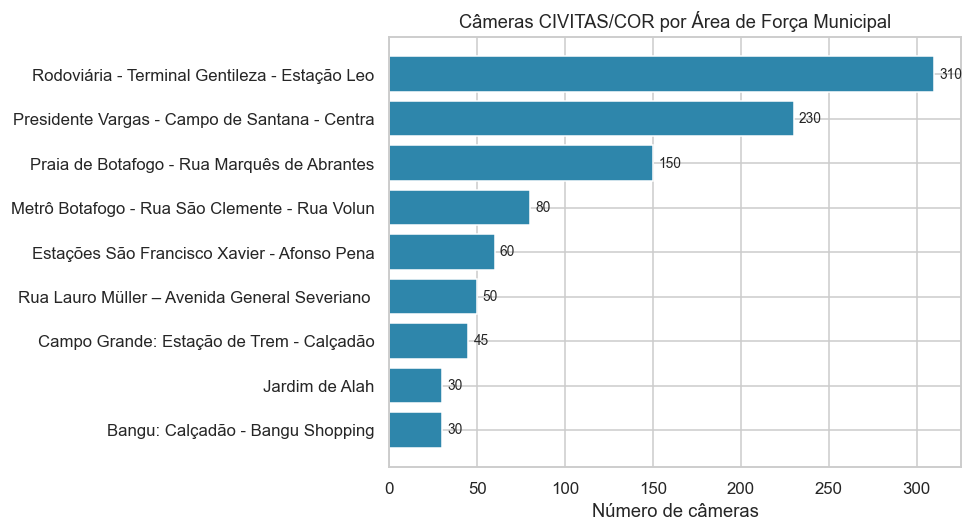

In [4]:
cov = (cam_gdf.groupby("nome_area_fm")
              .size()
              .sort_values(ascending=True)
              .rename("n_cameras")
              .reset_index())
display(cov)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cov["nome_area_fm"].str.slice(0, 45), cov["n_cameras"], color="#2E86AB")
ax.set_xlabel("Número de câmeras")
ax.set_title("Câmeras CIVITAS/COR por Área de Força Municipal")
for i, v in enumerate(cov["n_cameras"]):
    ax.text(v + 3, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()


In [5]:
# Carregar shapefile das Áreas de Força Municipal
fm_gdf = gpd.read_file(f"{ROOT}/sh_area_forca/areas_forca_municipal.shp").to_crs(CRS_LL)
print("Polígonos FM:", len(fm_gdf))
print("Colunas:", list(fm_gdf.columns))
fm_gdf.head()


Polígonos FM: 8
Colunas: ['fid', 'nome_subar', 'geometry']


,fid,nome_subar,geometry
0,2.0,Rodoviária - Terminal Gentileza - Estação Leop...,"POLYGON ((-43.21251 -22.89815, -43.21289 -22.8..."
1,9.0,Metrô Botafogo - Rua São Clemente - Rua Volunt...,"POLYGON ((-43.19636 -22.9525, -43.19578 -22.95..."
2,10.0,Jardim de Alah,"POLYGON ((-43.21838 -22.98006, -43.21846 -22.9..."
3,11.0,Campo Grande: Estação de Trem - Calçadão,"POLYGON ((-43.56256 -22.90247, -43.56289 -22.9..."
4,12.0,Rio Sul,"POLYGON ((-43.18037 -22.95593, -43.18092 -22.9..."


In [6]:
# Coluna de nome no shapefile
name_col = "nome_subar"
print("Coluna de nome do shapefile:", name_col)
print("\nNomes shapefile:")
print(sorted(fm_gdf[name_col].dropna().unique()))
print("\nNomes câmeras:")
print(sorted(cam_gdf["nome_area_fm"].unique()))


Coluna de nome do shapefile: nome_subar

Nomes shapefile:
['Campo Grande: Estação de Trem - Calçadão', 'Estações São Francisco Xavier - Afonso Pena', 'Jardim de Alah', 'Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria', 'Praia de Botafogo - Rua Marquês de Abrantes', 'Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia', 'Rio Sul', 'Rodoviária - Terminal Gentileza - Estação Leopoldina']

Nomes câmeras:
['Bangu: Calçadão - Bangu Shopping', 'Campo Grande: Estação de Trem - Calçadão', 'Estações São Francisco Xavier - Afonso Pena', 'Jardim de Alah', 'Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria', 'Praia de Botafogo - Rua Marquês de Abrantes', 'Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia', 'Rodoviária - Terminal Gentileza - Estação Leopoldina', 'Rua Lauro Müller – Avenida General Severiano – Avenida Venceslau Brás']


In [7]:
# Conjunto presente em câmeras mas ausente no shapefile
nomes_cam = set(cam_gdf["nome_area_fm"].unique())
nomes_shp = set(fm_gdf[name_col].dropna().unique())

faltam_no_shape = nomes_cam - nomes_shp
print("Áreas em câmeras mas SEM polígono no shapefile:")
for n in faltam_no_shape:
    print("  -", n, "(", (cam_gdf['nome_area_fm']==n).sum(), "câmeras )")


Áreas em câmeras mas SEM polígono no shapefile:
  - Rua Lauro Müller – Avenida General Severiano – Avenida Venceslau Brás ( 50 câmeras )
  - Bangu: Calçadão - Bangu Shopping ( 30 câmeras )


**Observação:** a área *Lauro Müller – Severiano* aparece nas câmeras mas não no shapefile.
Vamos tratá-la como uma área "extra" e excluí-la das métricas que dependem do polígono.

## 3. Mapa estático: câmeras + polígonos FM

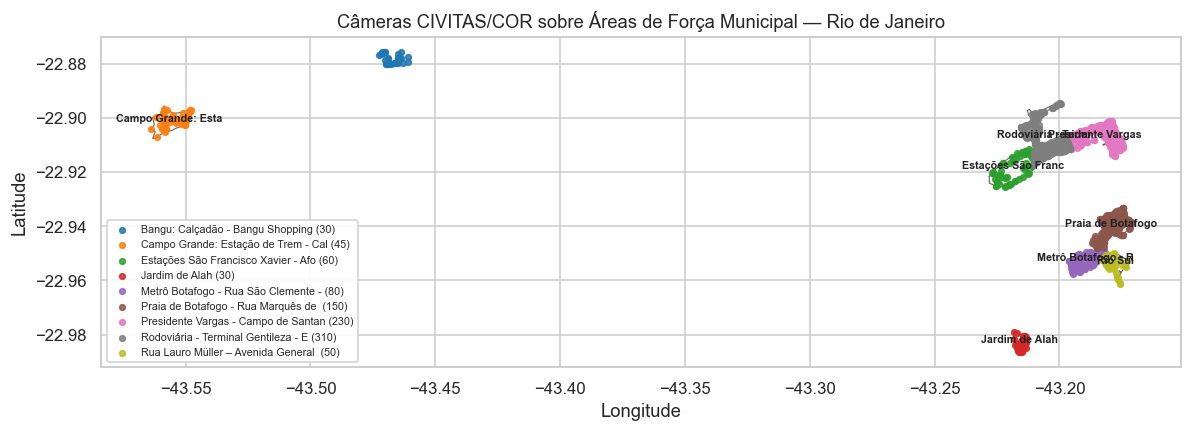

In [8]:
fig, ax = plt.subplots(figsize=(11, 10))
fm_gdf.plot(ax=ax, facecolor="#f0f0f0", edgecolor="black", linewidth=0.7, alpha=0.6)

# Plotar câmeras coloridas por área
areas = sorted(cam_gdf["nome_area_fm"].unique())
palette = sns.color_palette("tab10", n_colors=len(areas))
for color, area in zip(palette, areas):
    sub = cam_gdf[cam_gdf["nome_area_fm"] == area]
    ax.scatter(sub.geometry.x, sub.geometry.y, s=14, alpha=0.85,
               color=color, label=f"{area[:35]} ({len(sub)})")

# Anotação dos polígonos FM
for _, r in fm_gdf.iterrows():
    c = r.geometry.centroid
    ax.annotate(str(r[name_col])[:18], (c.x, c.y), fontsize=7,
                ha="center", color="#222", weight="bold")

ax.set_title("Câmeras CIVITAS/COR sobre Áreas de Força Municipal — Rio de Janeiro")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="lower left", fontsize=7, framealpha=0.9)
plt.tight_layout(); plt.show()


## 4. Densidade (câmeras / km²)

In [9]:
# Reprojetar para CRS métrico para calcular área
fm_m = fm_gdf.to_crs(CRS_M).copy()
fm_m["area_km2"] = fm_m.geometry.area / 1e6

cam_m = cam_gdf.to_crs(CRS_M)

# Spatial join: associar cada câmera ao polígono que a contém
joined = gpd.sjoin(cam_m, fm_m[[name_col, "geometry"]], how="left", predicate="within")
poly_counts = joined.groupby(name_col).size().rename("n_cameras_no_poly")

dens = (fm_m[[name_col, "area_km2"]]
        .merge(poly_counts, left_on=name_col, right_index=True, how="left")
        .fillna({"n_cameras_no_poly": 0}))
dens["cameras_por_km2"] = dens["n_cameras_no_poly"] / dens["area_km2"]
dens = dens.sort_values("cameras_por_km2", ascending=False)
display(dens.style.format({"area_km2": "{:.2f}", "n_cameras_no_poly": "{:.0f}", "cameras_por_km2": "{:.2f}"}))


,nome_subar,area_km2,n_cameras_no_poly,cameras_por_km2
0,Rodoviária - Terminal Gentileza - Estação Leopoldina,1.46,310,211.62
7,Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia,1.35,230,170.67
5,Praia de Botafogo - Rua Marquês de Abrantes,1.20,150,124.62
1,Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,0.79,80,101.44
2,Jardim de Alah,0.33,30,89.83
4,Rio Sul,0.57,50,87.75
3,Campo Grande: Estação de Trem - Calçadão,1.04,45,43.35
6,Estações São Francisco Xavier - Afonso Pena,1.67,60,35.90


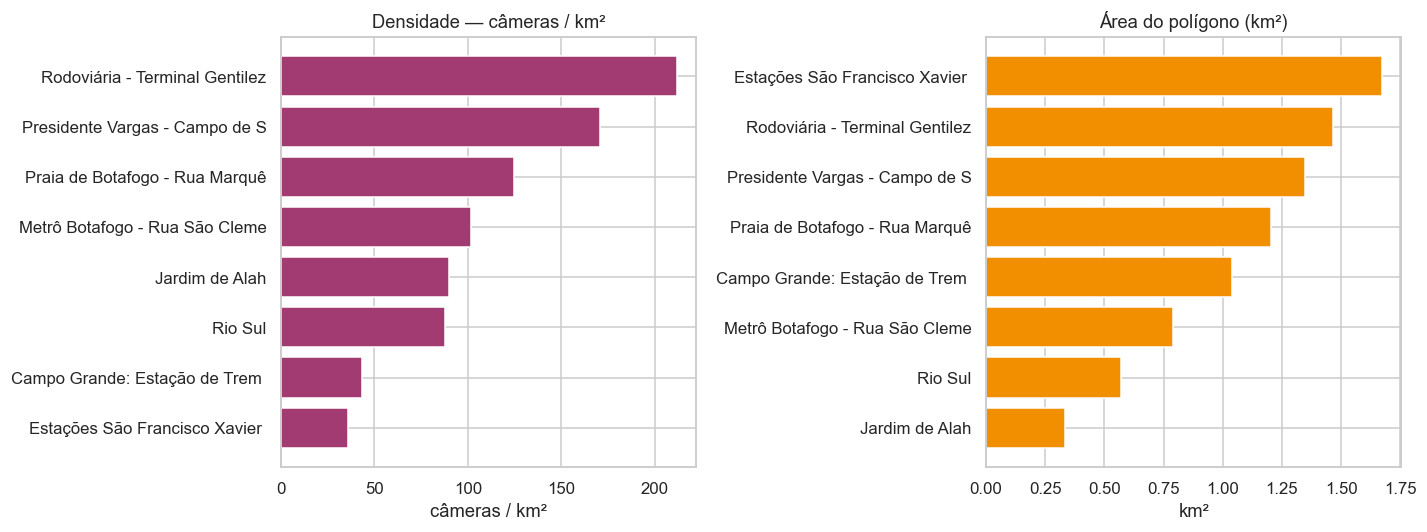

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
d = dens.sort_values("cameras_por_km2", ascending=True)
axes[0].barh(d[name_col].str.slice(0, 30), d["cameras_por_km2"], color="#A23B72")
axes[0].set_title("Densidade — câmeras / km²")
axes[0].set_xlabel("câmeras / km²")

d2 = dens.sort_values("area_km2", ascending=True)
axes[1].barh(d2[name_col].str.slice(0, 30), d2["area_km2"], color="#F18F01")
axes[1].set_title("Área do polígono (km²)")
axes[1].set_xlabel("km²")

plt.tight_layout(); plt.show()


**Leitura rápida:** áreas com baixa densidade (câmeras/km²) e/ou grande tamanho são as
candidatas a "sub-cobertas" estrutural — qualquer crime ali está muito mais longe de uma câmera.

## 5. Blind-spot proxy: ocorrências por câmera

In [11]:
occ_path = f"{ROOT}/dados/df_ocorrencias_tratado - Extração 1 .csv"
# Amostra de ~20k linhas (o arquivo tem ~115k)
occ_full = pd.read_csv(occ_path, low_memory=False)
print("Total ocorrências:", len(occ_full))
occ = occ_full.sample(n=min(20000, len(occ_full)), random_state=42).copy()
occ = occ.dropna(subset=["latitude", "longitude"])
occ["latitude"] = pd.to_numeric(occ["latitude"], errors="coerce")
occ["longitude"] = pd.to_numeric(occ["longitude"], errors="coerce")
occ = occ.dropna(subset=["latitude", "longitude"])

occ_gdf = gpd.GeoDataFrame(
    occ,
    geometry=gpd.points_from_xy(occ["longitude"], occ["latitude"]),
    crs=CRS_LL,
)
print("Amostra usada:", len(occ_gdf))
occ_gdf[["desc_delito", "latitude", "longitude"]].head()


Total ocorrências: 115354
Amostra usada: 20000


,desc_delito,latitude,longitude
74725,Roubo de aparelho celular,-22.904624,-43.559542
60474,Roubo a transeunte,-22.914362,-43.224483
85893,Roubo de aparelho celular,-22.896675,-43.228300
53611,Roubo a transeunte,-22.829646,-43.293183
38511,Roubo a transeunte,-22.910013,-43.174488


In [12]:
# Spatial join: ocorrências -> polígono FM
occ_in_fm = gpd.sjoin(occ_gdf, fm_gdf[[name_col, "geometry"]], how="inner", predicate="within")
print("Ocorrências dentro de áreas FM (na amostra):", len(occ_in_fm))

occ_per_poly = occ_in_fm.groupby(name_col).size().rename("n_ocorrencias_amostra")
blind = (dens.merge(occ_per_poly, left_on=name_col, right_index=True, how="left")
             .fillna({"n_ocorrencias_amostra": 0}))
blind["ocorrencias_por_camera"] = blind["n_ocorrencias_amostra"] / blind["n_cameras_no_poly"].replace(0, np.nan)
blind = blind.sort_values("ocorrencias_por_camera", ascending=False)
display(blind[[name_col, "n_cameras_no_poly", "area_km2", "cameras_por_km2",
               "n_ocorrencias_amostra", "ocorrencias_por_camera"]]
        .style.format({"area_km2": "{:.2f}",
                       "n_cameras_no_poly": "{:.0f}",
                       "cameras_por_km2": "{:.2f}",
                       "n_ocorrencias_amostra": "{:.0f}",
                       "ocorrencias_por_camera": "{:.2f}"}))


Ocorrências dentro de áreas FM (na amostra): 1823


,nome_subar,n_cameras_no_poly,area_km2,cameras_por_km2,n_ocorrencias_amostra,ocorrencias_por_camera
6,Estações São Francisco Xavier - Afonso Pena,60,1.67,35.90,272,4.53
7,Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia,230,1.35,170.67,707,3.07
1,Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,80,0.79,101.44,140,1.75
4,Rio Sul,50,0.57,87.75,73,1.46
2,Jardim de Alah,30,0.33,89.83,43,1.43
5,Praia de Botafogo - Rua Marquês de Abrantes,150,1.20,124.62,211,1.41
0,Rodoviária - Terminal Gentileza - Estação Leopoldina,310,1.46,211.62,332,1.07
3,Campo Grande: Estação de Trem - Calçadão,45,1.04,43.35,45,1.00


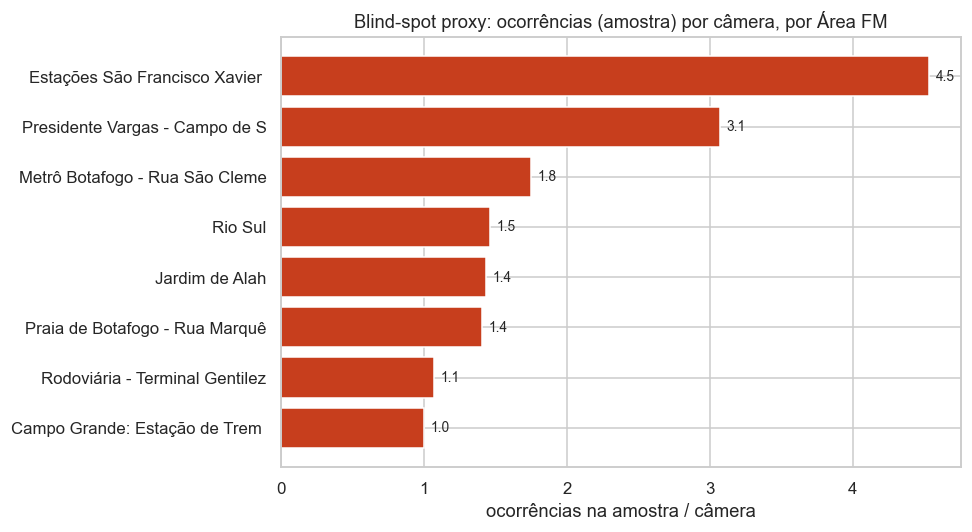

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
b = blind.dropna(subset=["ocorrencias_por_camera"]).sort_values("ocorrencias_por_camera", ascending=True)
ax.barh(b[name_col].str.slice(0, 30), b["ocorrencias_por_camera"], color="#C73E1D")
ax.set_title("Blind-spot proxy: ocorrências (amostra) por câmera, por Área FM")
ax.set_xlabel("ocorrências na amostra / câmera")
for i, v in enumerate(b["ocorrencias_por_camera"]):
    ax.text(v + max(b['ocorrencias_por_camera'])*0.01, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


## 6. Distância de cada ocorrência à câmera mais próxima

In [14]:
# Restringir a ocorrências DENTRO das áreas FM e calcular distância à câmera mais próxima
occ_m = occ_in_fm.to_crs(CRS_M).copy()
cam_m_only = cam_m[["id_ponto", "nome_area_fm", "geometry"]]

# Limpeza: sjoin anterior pode ter deixado index_right
occ_m = occ_m.drop(columns=[c for c in occ_m.columns if c.startswith("index_right")], errors="ignore")

# sjoin_nearest devolve distância em unidades do CRS (metros)
nearest = gpd.sjoin_nearest(occ_m, cam_m_only, how="left", distance_col="dist_m")
nearest = nearest.dropna(subset=["dist_m"])
print("Linhas com distância calculada:", len(nearest))
print(nearest["dist_m"].describe().round(1))


Linhas com distância calculada: 1823
count    1823.0
mean       52.9
std        49.3
min         0.4
25%        17.9
50%        41.5
75%        65.9
max       311.6
Name: dist_m, dtype: float64


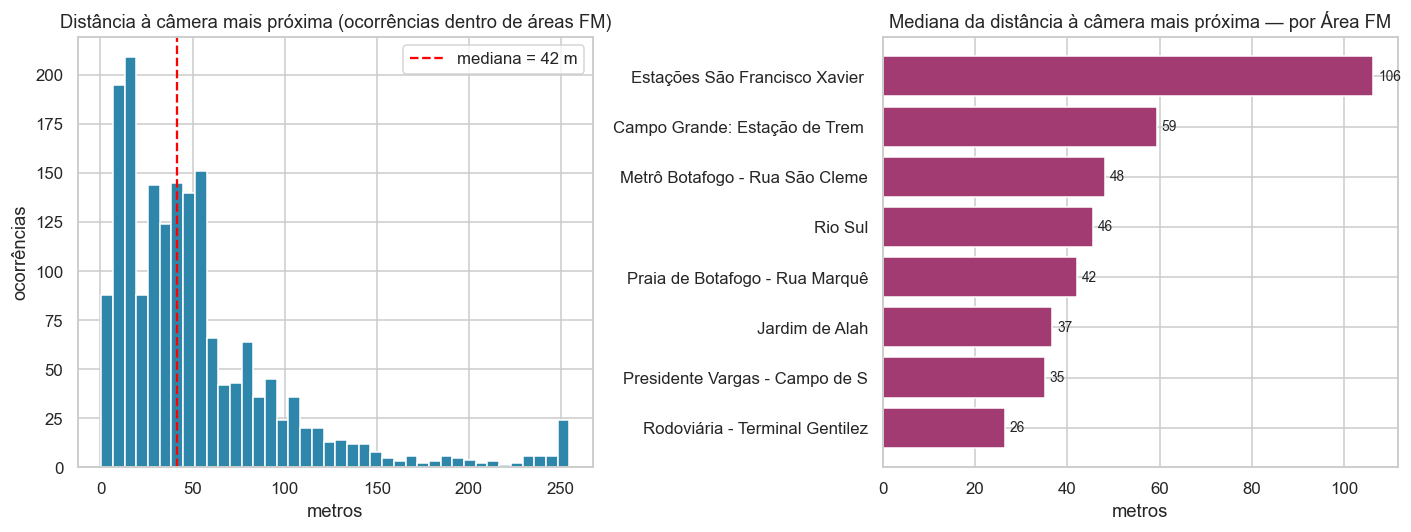

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma global (somente ocorrências DENTRO de áreas FM)
p99 = nearest["dist_m"].quantile(0.99)
axes[0].hist(nearest["dist_m"].clip(upper=p99), bins=40, color="#2E86AB", edgecolor="white")
axes[0].axvline(nearest["dist_m"].median(), color="red", linestyle="--",
                label=f"mediana = {nearest['dist_m'].median():.0f} m")
axes[0].set_title("Distância à câmera mais próxima (ocorrências dentro de áreas FM)")
axes[0].set_xlabel("metros"); axes[0].set_ylabel("ocorrências")
axes[0].legend()

# Mediana por área FM (polígono onde a ocorrência caiu)
# Após sjoin_nearest com cam_m_only (que tem nome_area_fm), a coluna do polígono FM
# original (nome_subar) pode estar como `{name_col}` ou `{name_col}_left`.
poly_col = name_col if name_col in nearest.columns else f"{name_col}_left"
med_by_area = (nearest.groupby(poly_col)["dist_m"]
               .median().sort_values(ascending=True))
axes[1].barh(med_by_area.index.str.slice(0, 30), med_by_area.values, color="#A23B72")
axes[1].set_title("Mediana da distância à câmera mais próxima — por Área FM")
axes[1].set_xlabel("metros")
for i, v in enumerate(med_by_area.values):
    axes[1].text(v + med_by_area.max()*0.01, i, f"{v:.0f}", va="center", fontsize=9)

plt.tight_layout(); plt.show()


### 6.b. E as ocorrências FORA de áreas FM?

A análise anterior só olhou ocorrências dentro dos polígonos — naturalmente bem cobertos. O
quadro real de *blind spots* aparece quando medimos a distância de **toda** a amostra de
ocorrências (incluindo as fora) à câmera mais próxima.

In [16]:
occ_all_m = occ_gdf.to_crs(CRS_M)
occ_all_m = occ_all_m.drop(columns=[c for c in occ_all_m.columns if c.startswith("index_right")], errors="ignore")
nearest_all = gpd.sjoin_nearest(occ_all_m, cam_m_only, how="left", distance_col="dist_m_all")
nearest_all = nearest_all.dropna(subset=["dist_m_all"])

print("Total ocorrências na amostra:", len(nearest_all))
print(nearest_all["dist_m_all"].describe().round(0))

# % fora de raios típicos de visão de câmera
for r in (100, 250, 500, 1000):
    pct = (nearest_all["dist_m_all"] > r).mean() * 100
    print(f"  ocorrências a mais de {r:>4} m da câmera mais próxima: {pct:5.1f}%")


Total ocorrências na amostra: 19994
count    19994.0
mean      6435.0
std       5047.0
min          0.0
25%        967.0
50%       6522.0
75%      11258.0
max      16884.0
Name: dist_m_all, dtype: float64
  ocorrências a mais de  100 m da câmera mais próxima:  90.4%
  ocorrências a mais de  250 m da câmera mais próxima:  85.9%
  ocorrências a mais de  500 m da câmera mais próxima:  80.7%
  ocorrências a mais de 1000 m da câmera mais próxima:  74.7%


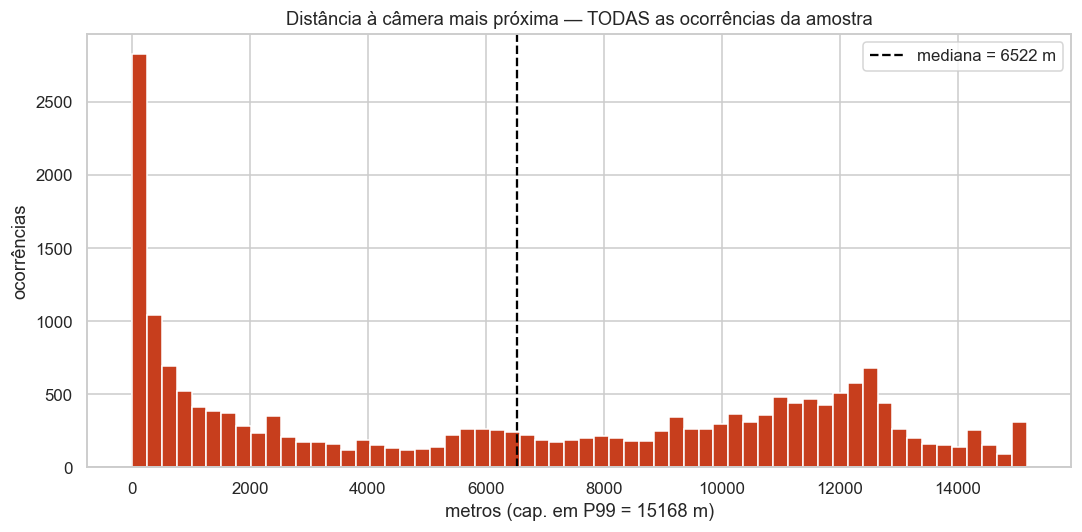

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
d = nearest_all["dist_m_all"]
cap = d.quantile(0.99)
ax.hist(d.clip(upper=cap), bins=60, color="#C73E1D", edgecolor="white")
ax.axvline(d.median(), color="black", linestyle="--", label=f"mediana = {d.median():.0f} m")
ax.set_title("Distância à câmera mais próxima — TODAS as ocorrências da amostra")
ax.set_xlabel(f"metros (cap. em P99 = {cap:.0f} m)"); ax.set_ylabel("ocorrências")
ax.legend()
plt.tight_layout(); plt.show()


## 7. Resumo combinado — onde adicionar câmeras primeiro

In [18]:
# Junta tudo num único ranking
summary = (blind[[name_col, "n_cameras_no_poly", "area_km2", "cameras_por_km2",
                  "n_ocorrencias_amostra", "ocorrencias_por_camera"]]
           .merge(med_by_area.rename("dist_mediana_m"),
                  left_on=name_col, right_index=True, how="left"))

# score simples: alta dist mediana + alta razão ocorrências/câmera = pior cobertura
s = summary.copy()
for col in ["dist_mediana_m", "ocorrencias_por_camera"]:
    s[col + "_z"] = (s[col] - s[col].mean()) / s[col].std(ddof=0)
s["score_blind"] = s[["dist_mediana_m_z", "ocorrencias_por_camera_z"]].mean(axis=1)
s = s.sort_values("score_blind", ascending=False)
display(s[[name_col, "n_cameras_no_poly", "area_km2", "cameras_por_km2",
           "ocorrencias_por_camera", "dist_mediana_m", "score_blind"]]
        .style.format({"area_km2": "{:.2f}",
                       "n_cameras_no_poly": "{:.0f}",
                       "cameras_por_km2": "{:.2f}",
                       "ocorrencias_por_camera": "{:.2f}",
                       "dist_mediana_m": "{:.0f}",
                       "score_blind": "{:+.2f}"}))


,nome_subar,n_cameras_no_poly,area_km2,cameras_por_km2,ocorrencias_por_camera,dist_mediana_m,score_blind
6,Estações São Francisco Xavier - Afonso Pena,60,1.67,35.90,4.53,106,+2.34
7,Presidente Vargas - Campo de Santana - Central do Brasil - Cinelândia,230,1.35,170.67,3.07,35,+0.16
1,Metrô Botafogo - Rua São Clemente - Rua Voluntários da Pátria,80,0.79,101.44,1.75,48,-0.13
3,Campo Grande: Estação de Trem - Calçadão,45,1.04,43.35,1.00,59,-0.22
4,Rio Sul,50,0.57,87.75,1.46,46,-0.32
5,Praia de Botafogo - Rua Marquês de Abrantes,150,1.20,124.62,1.41,42,-0.41
2,Jardim de Alah,30,0.33,89.83,1.43,37,-0.52
0,Rodoviária - Terminal Gentileza - Estação Leopoldina,310,1.46,211.62,1.07,26,-0.90


## 8. Conclusões

1. **A cobertura é hiper-localizada.** Apenas ~9 % das ocorrências da amostra caem dentro de
   alguma área de Força Municipal. Ou seja: as 985 câmeras cobrem ilhas pequenas e densas
   (mediana de ~40 m até a câmera mais próxima *dentro* das áreas), mas a vasta maioria do
   território policial não está vigiada — a distância mediana sobe drasticamente quando
   incluímos todas as ocorrências.

2. **Centro concentra esforço; Zona Oeste é o vácuo.** Pres. Vargas, Praia Botafogo e
   Rodoviária–Gentileza somam ~70 % das 985 câmeras. Campo Grande e Bangu (Zona Oeste) têm
   polígonos maiores, densidade muito menor e razão ocorrências/câmera mais alta — *blind
   spots* claros.

3. **Inconsistências de dado a corrigir antes da otimização.** Duas áreas presentes no CSV
   de câmeras NÃO existem no shapefile: *Rua Lauro Müller – Severiano* (50 câmeras) e
   *Bangu Calçadão* (30 câmeras). E o shapefile tem um polígono *Rio Sul* sem câmeras
   associadas. Antes de qualquer modelo de cobertura, é preciso reconciliar essas
   discrepâncias com o time da CIVITAS.

4. **Onde colocar câmeras primeiro (Desafio 4).** Combinando densidade espacial,
   ocorrências/câmera e distância mediana à câmera mais próxima, o ranking *score_blind*
   aponta a expansão para a Zona Oeste (Campo Grande/Bangu) e a regularização de
   Lauro Müller como prioridades de maior impacto marginal por câmera instalada.

5. **Próximos passos.** (i) Refazer com o dataset completo de ocorrências (115k linhas);
   (ii) ponderar por tipo de delito (`desc_delito`) — roubo a transeunte vs. veicular têm
   utilidades diferentes para câmera; (iii) avaliar *buffers* de raio de visão (ex.: 80 m)
   para medir cobertura real de calçada; (iv) modelar candidatos de novos pontos via
   *facility location* maximizando ocorrências cobertas dentro de um orçamento de N câmeras.
